In [1]:
from myutils import cache
from matplotlib import pyplot as plt
plt.rcdefaults()
from src import *

In [2]:
width = 8.5 / 2.54 #inches

plt.rcParams['text.usetex'] = True
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics, newtxtext, newtxmath, courier, fix-cm, helvet}'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics}'

formatter = ScalarFormatter(useMathText=True)
formatter.set_useOffset(False)  
formatter.set_powerlimits((0, 0))


In [ ]:
spade_params = {
    'marker': 'o',
    'edgecolors': 'tab:blue',
    'facecolors': '#ffffff',
    's': 6,
    'linewidths': 0.8,
    'alpha': 1
}

di_params = {
    'marker': 'P',
    'edgecolors': '#ffffff',
    'facecolor': 'k',
    's': 6,
    'linewidths': 0.1,
    'alpha': 1,
    'rasterized': True
}

hg_params = {
    'marker': 'D',
    'edgecolors': 'tab:green',
    'facecolors': '#ffffff',
    's': 5,
    'linewidths': 0.8,
    'alpha': 1
}

crb_color = 'tab:gray'
qcrb_color = 'tab:red'

In [4]:
@cache
def run_sim_fig4():
    sim = Simulator('hg', DMD.A(5), 0.2, waveform='sin')

    hg_mean, hg_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*60, 60)
        c.est()
        hg_mean.append(c.estimates.mean())
        hg_var.append(c.photons * c.estimates.var(0, ddof=1))

    sim = Simulator('pm', DMD.A(5), 0.2, waveform='sin')

    pm_mean, pm_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*60, 60)
        c.est()
        pm_mean.append(c.estimates.mean())
        pm_var.append(c.photons * c.estimates.var(0, ddof=1))

    sim = Simulator('di', DMD.A(5), 0.2, waveform='sin')

    di_mean, di_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*400, 400)
        c.est()
        di_mean.append(c.estimates.mean())
        di_var.append(c.photons * c.estimates.var(0, ddof=1))

    means = [hg_mean, pm_mean, di_mean]
    vars = [hg_var, pm_var, di_var]
    return means, vars


In [24]:
means, vars = run_sim_fig4()

cache hit: reading result from cache file


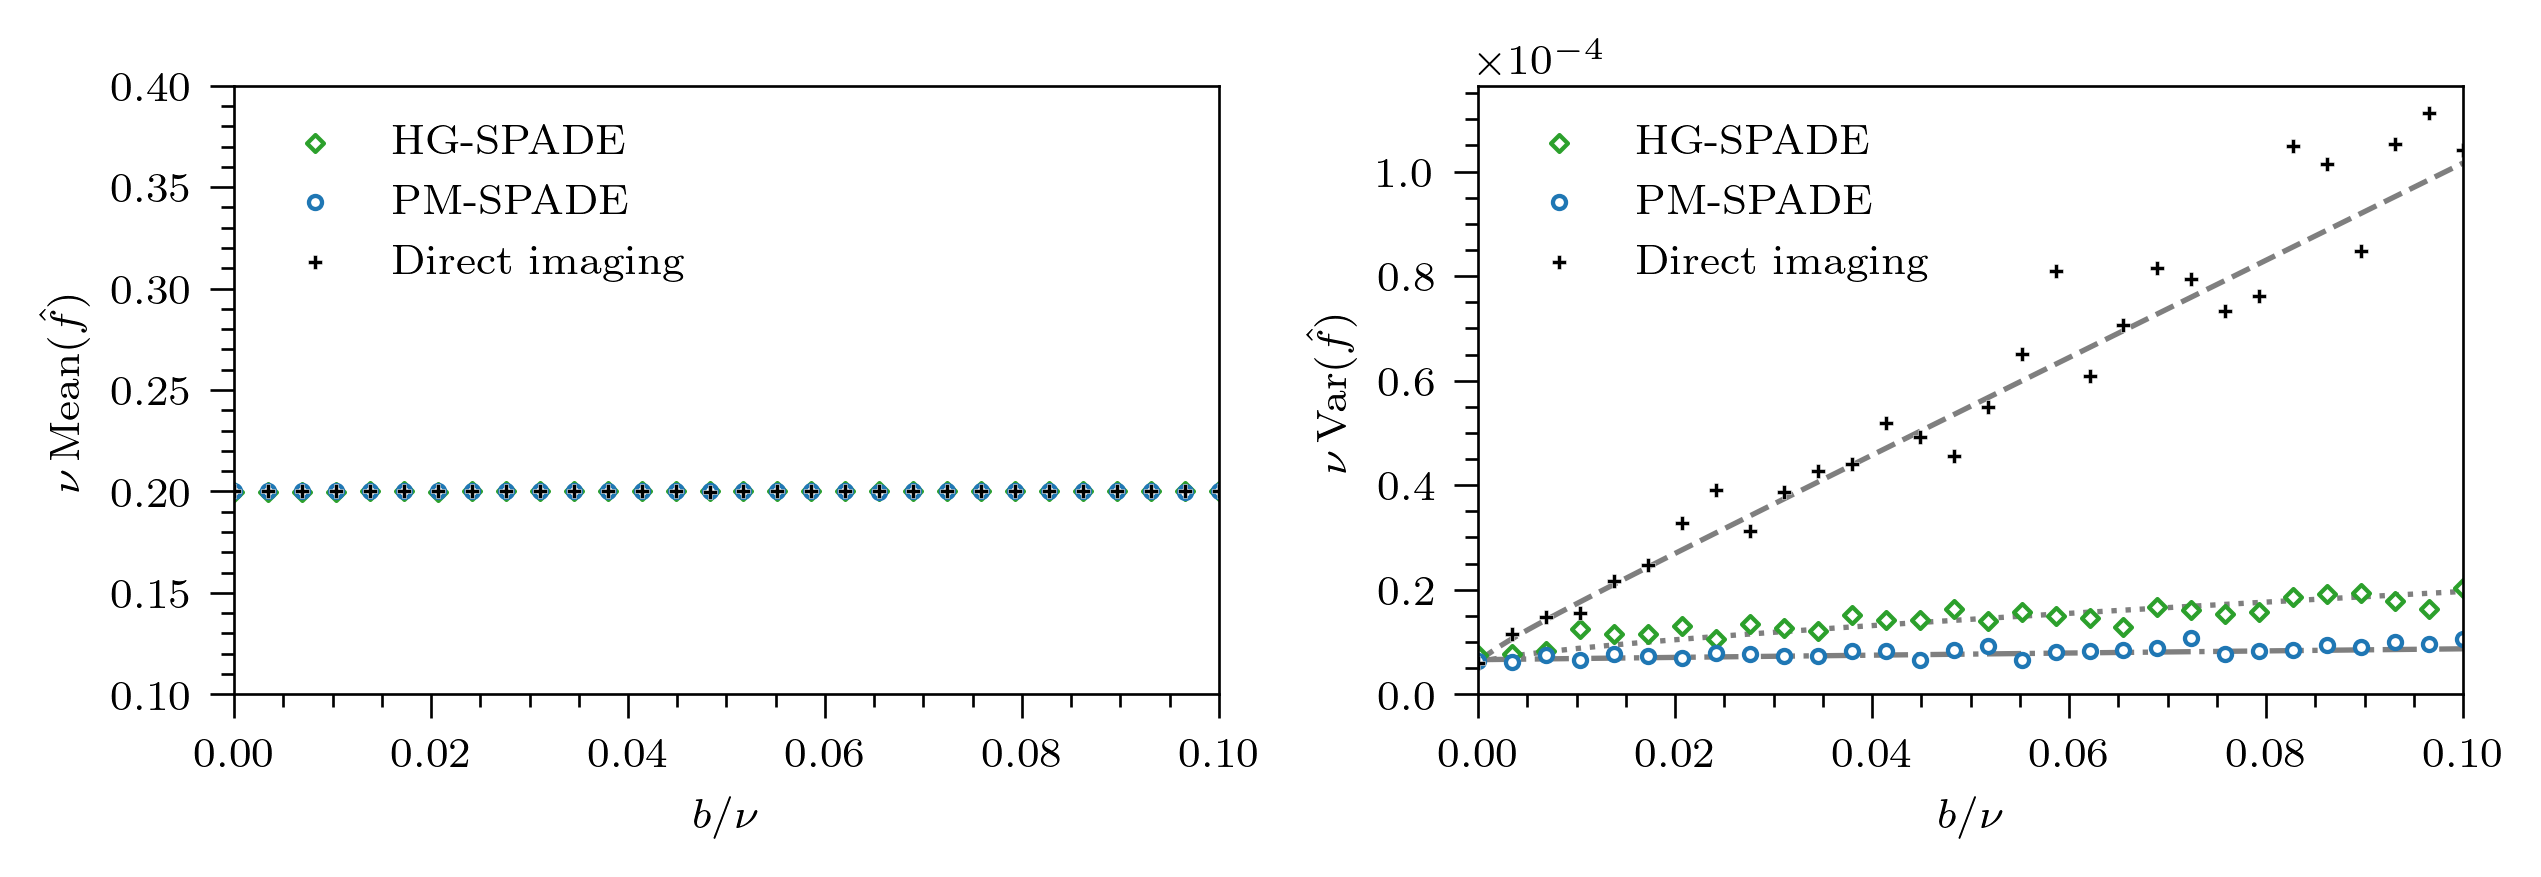

In [25]:
plt.rcParams['figure.figsize'] = (6.6, 3)

plt.subplot(1, 2, 1) 

plt.scatter(np.linspace(0, 0.1, 30), np.array(means[0]), label=r'HG-SPADE', **hg_params)
plt.scatter(np.linspace(0, 0.1, 30), np.array(means[1]), label=r'PM-SPADE', **spade_params)
plt.scatter(np.linspace(0, 0.1, 30), np.array(means[2]), label=r'Direct imaging', **di_params)

plt.legend(frameon=False, loc='upper left')
plt.xlim(0, 0.1)
plt.ylim(0.1, 0.4)

plt.xlabel(r'$b/\nu$')
plt.ylabel(r'$\nu \operatorname{Mean}(\hat f)$')

plt.gca().set_box_aspect(0.618)


plt.subplot(1, 2, 2)

plt.plot(np.linspace(0, 0.1, 100), 1/HG_SPADE.CFI(np.linspace(0, 0.1, 100), DMD.A(5), 0.2), ':', color='tab:gray', zorder=0)
plt.plot(np.linspace(0, 0.1, 100), 1/PM_SPADE.CFI(np.linspace(0, 0.1, 100), DMD.A(5), 0.2), '-.', color='tab:gray', zorder=0)
plt.plot(np.linspace(0, 0.1, 100), 1/DI.CFI(np.linspace(0, 0.1, 100), DMD.A(5), 0.2), '--', color='tab:gray', zorder=0)

plt.scatter(np.linspace(0, 0.1, 30), np.array(vars[0]), label=r'HG-SPADE', **hg_params)
plt.scatter(np.linspace(0, 0.1, 30), np.array(vars[1]), label=r'PM-SPADE', **spade_params)
plt.scatter(np.linspace(0, 0.1, 30), np.array(vars[2]), label=r'Direct imaging', **di_params)


plt.xlabel(r'$b/\nu$')
plt.ylabel(r'$\nu \operatorname{Var}(\hat f)$')
plt.legend(frameon=False, loc='upper left')
plt.xlim(0, 0.1)
plt.ylim(0, None)

plt.gca().yaxis.set_major_formatter(formatter)
plt.gca().set_box_aspect(0.618)

plt.tight_layout()
plt.show()

In [14]:
@cache
def run_sim_fig4_sign():
    sim = Simulator('hg', DMD.A(5), 0.2)

    hg_mean, hg_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*60, 60)
        c.est()
        hg_mean.append(c.estimates.mean())
        hg_var.append(c.photons * c.estimates.var(0, ddof=1))

    sim = Simulator('pm', DMD.A(5), 0.2)

    pm_mean, pm_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*60, 60)
        c.est()
        pm_mean.append(c.estimates.mean())
        pm_var.append(c.photons * c.estimates.var(0, ddof=1))

    sim = Simulator('di', DMD.A(5), 0.2)

    di_mean, di_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*400, 400)
        c.est()
        di_mean.append(c.estimates.mean())
        di_var.append(c.photons * c.estimates.var(0, ddof=1))

    means = [hg_mean, pm_mean, di_mean]
    vars = [hg_var, pm_var, di_var]
    return means, vars


In [26]:
means, vars = run_sim_fig4_sign()

cache hit: reading result from cache file


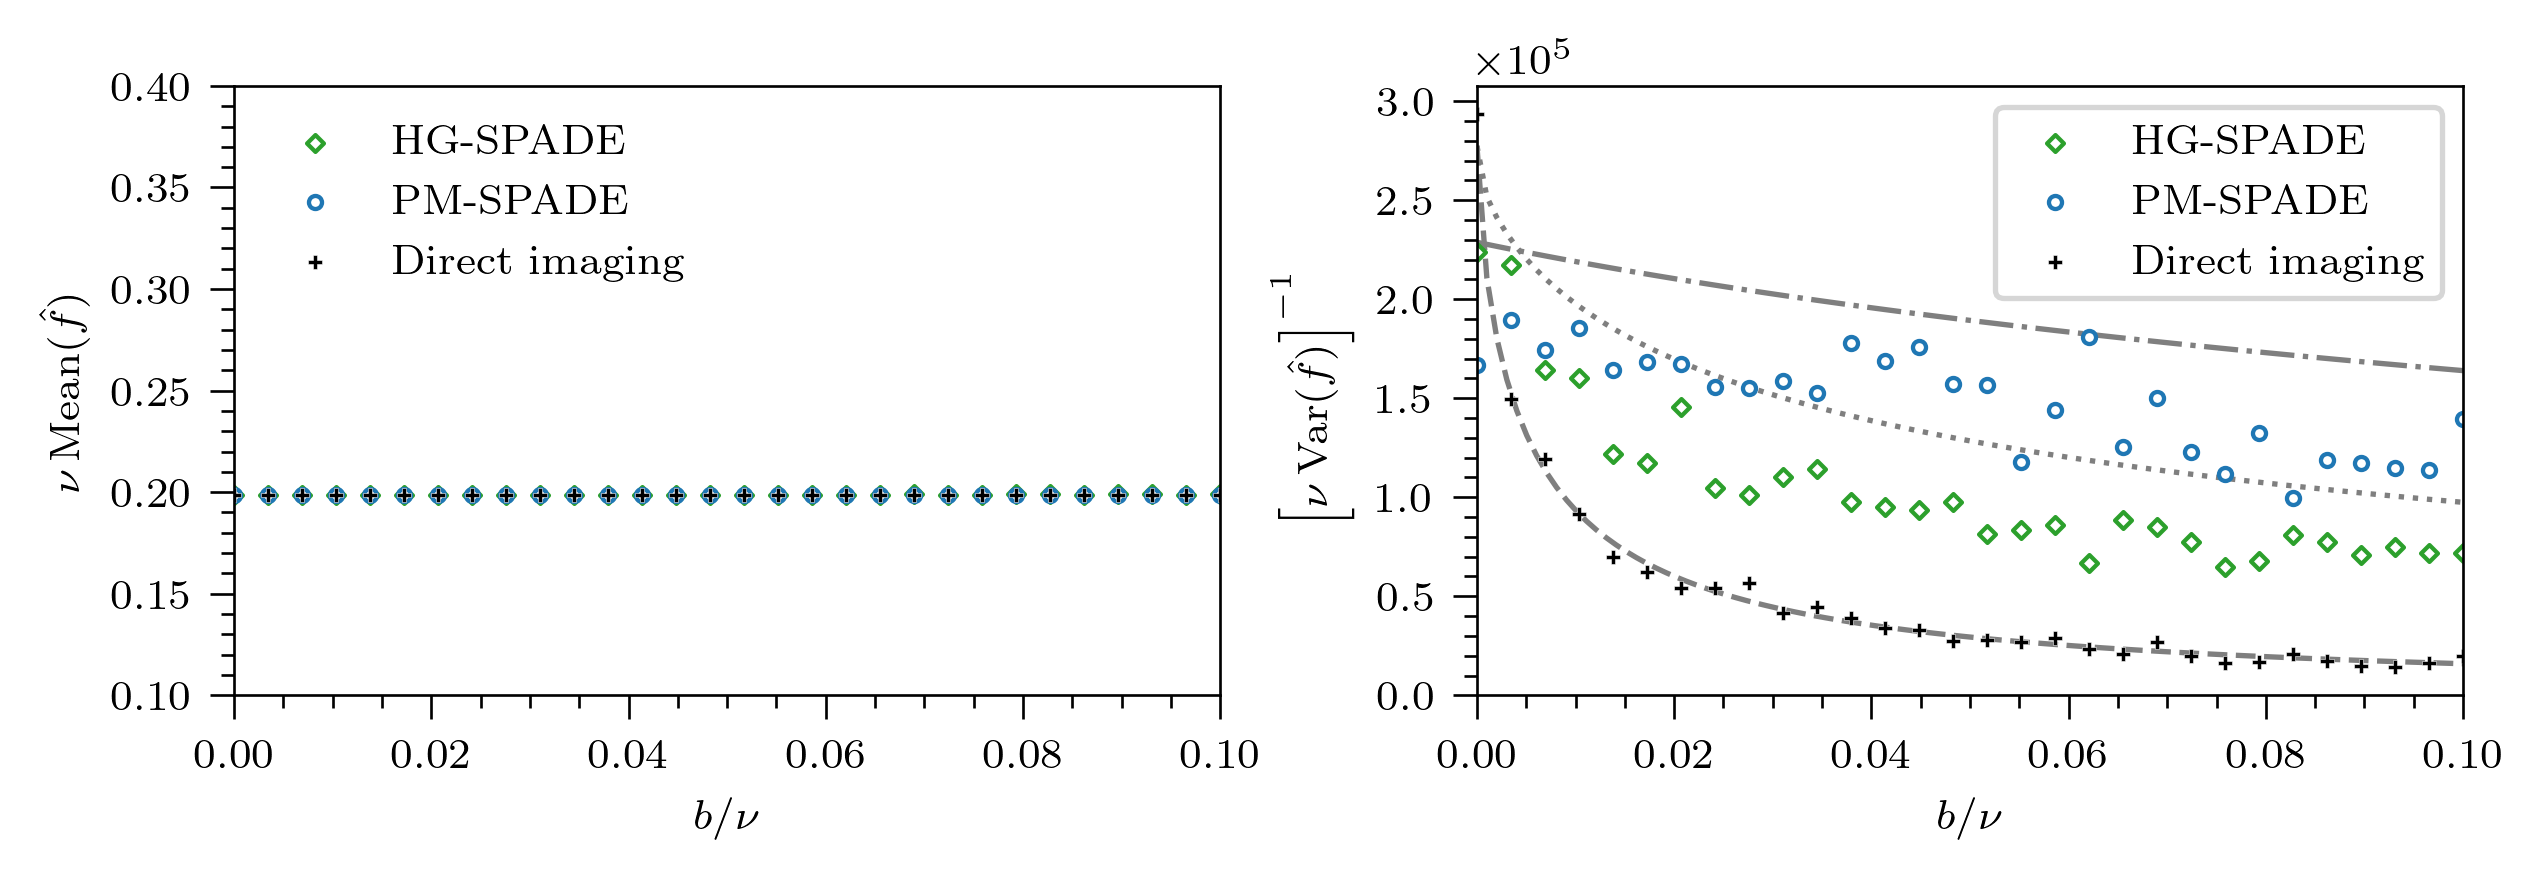

In [31]:
plt.rcParams['figure.figsize'] = (6.6, 3)

plt.subplot(1, 2, 1) 

plt.scatter(np.linspace(0, 0.1, 30), np.array(means[0]), label=r'HG-SPADE', **hg_params)
plt.scatter(np.linspace(0, 0.1, 30), np.array(means[1]), label=r'PM-SPADE', **spade_params)
plt.scatter(np.linspace(0, 0.1, 30), np.array(means[2]), label=r'Direct imaging', **di_params)

plt.legend(frameon=False, loc='upper left')
plt.xlim(0, 0.1)
plt.ylim(0.1, 0.4)

plt.xlabel(r'$b/\nu$')
plt.ylabel(r'$\nu \operatorname{Mean}(\hat f)$')

plt.gca().set_box_aspect(0.618)


plt.subplot(1, 2, 2)

plt.plot(np.linspace(0, 0.1, 100), HG_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), ':', color='tab:gray', zorder=0)
plt.plot(np.linspace(0, 0.1, 100), PM_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), '-.', color='tab:gray', zorder=0)
plt.plot(np.linspace(0, 0.1, 100), DI.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), '--', color='tab:gray', zorder=0)

plt.scatter(np.linspace(0, 0.1, 30), 1/np.array(vars[0]), label=r'HG-SPADE', **hg_params)
plt.scatter(np.linspace(0, 0.1, 30), 1/np.array(vars[1]), label=r'PM-SPADE', **spade_params)
plt.scatter(np.linspace(0, 0.1, 30), 1/np.array(vars[2]), label=r'Direct imaging', **di_params)


plt.xlabel(r'$b/\nu$')
plt.ylabel(r'$\qty[\nu \operatorname{Var}(\hat f)]^{-1}$')
plt.legend(frameon=True, loc='upper right')
plt.xlim(0, 0.1)
plt.ylim(0, None)

plt.gca().yaxis.set_major_formatter(formatter)
plt.gca().set_box_aspect(0.618)

plt.tight_layout()
plt.show()

In [36]:
@cache
def run_sim_fig3():
    hg_mean, hg_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('hg', DMD.A(5), f, waveform='sin').gen()
        c.est()
        hg_mean.append(c.estimates.mean())
        hg_var.append(c.estimates.var() * c.photons)


    pm_mean, pm_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('pm', DMD.A(5), f, waveform='sin').gen()
        c.est()
        pm_mean.append(c.estimates.mean())
        pm_var.append(c.estimates.var() * c.photons)


    di_mean, di_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('di', DMD.A(5), f, waveform='sin').gen()
        c.est()
        di_mean.append(c.estimates.mean())
        di_var.append(c.estimates.var() * c.photons)

    means = [hg_mean, pm_mean, di_mean]
    vars = [hg_var, pm_var, di_var]
    return means, vars

In [33]:
means, vars = run_sim_fig3()

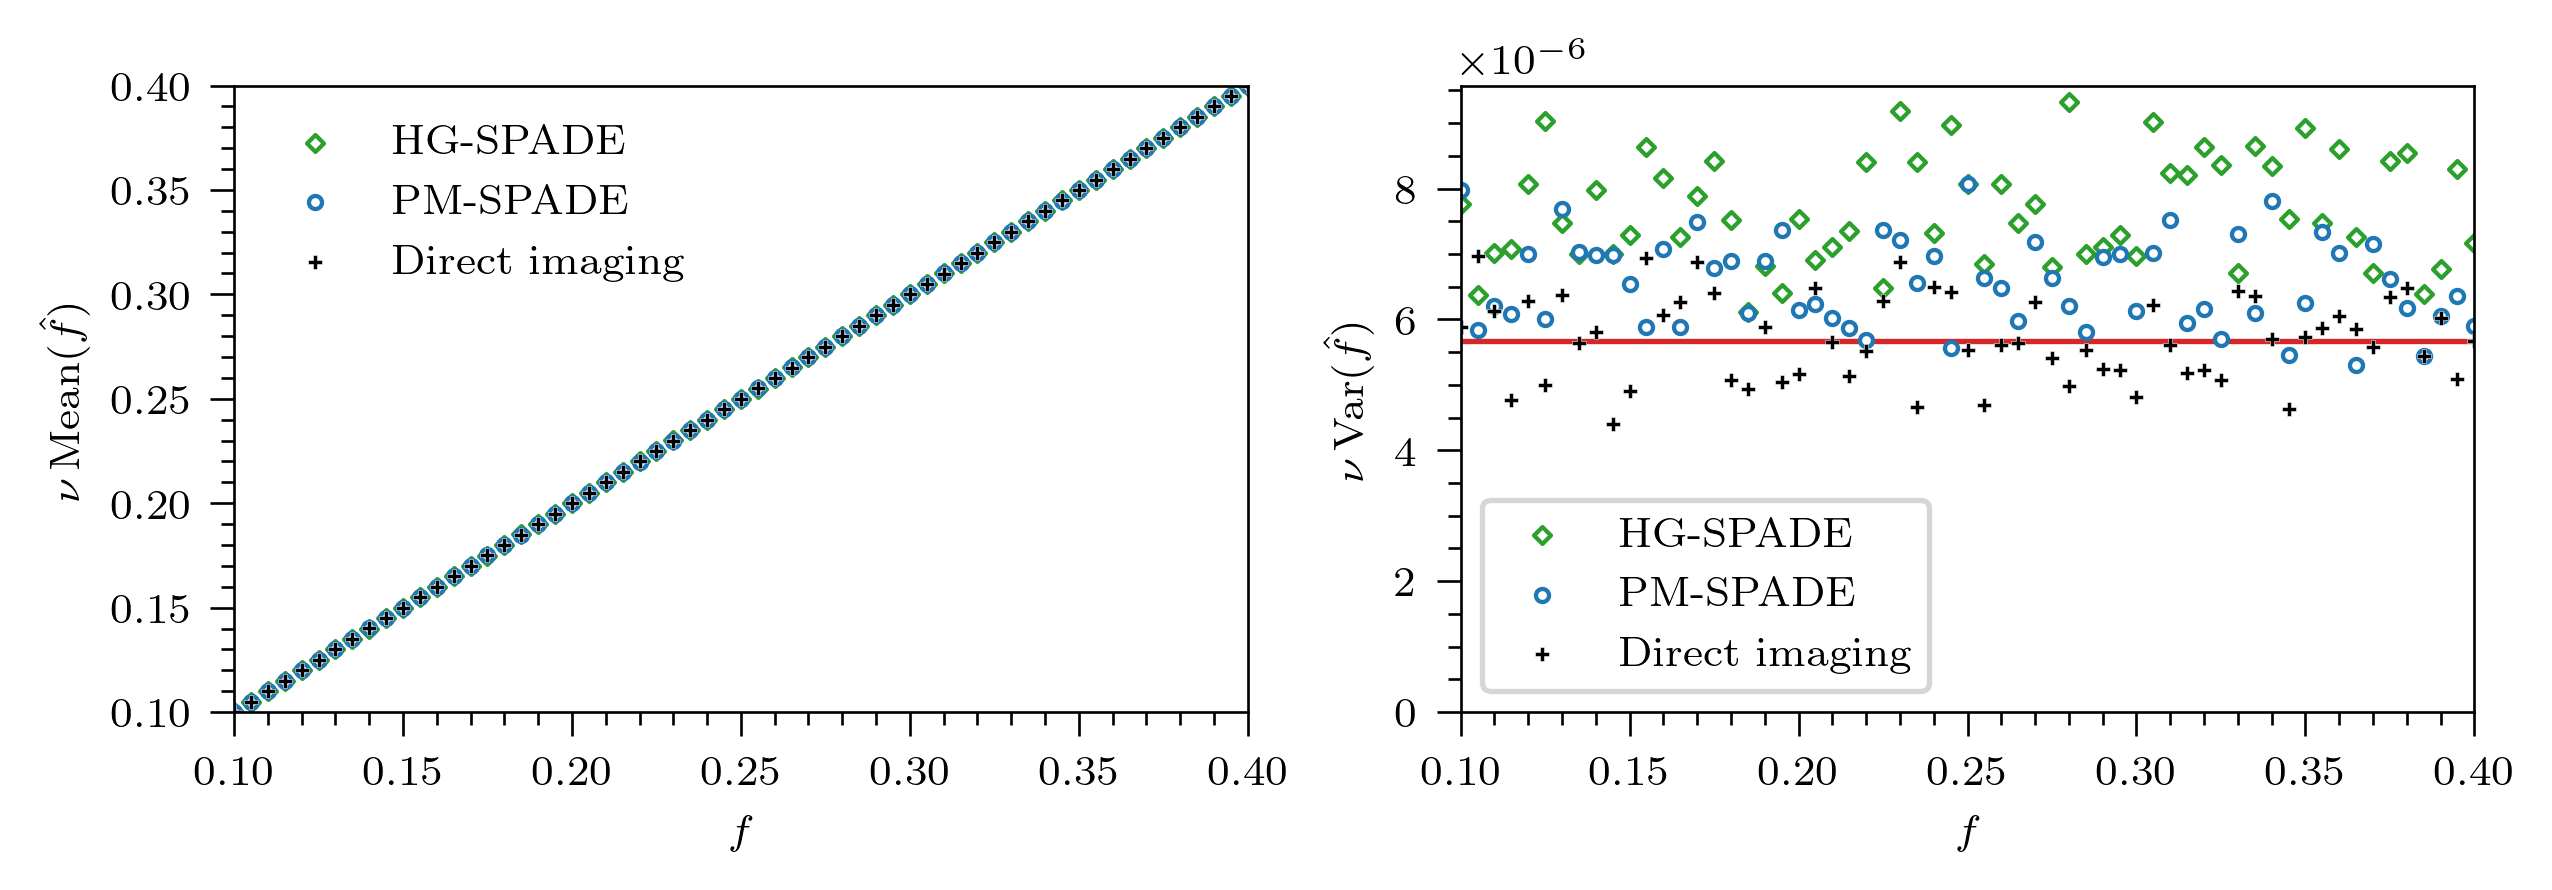

In [34]:
plt.rcParams['figure.figsize'] = (6.6, 3)

plt.subplot(1, 2, 1)

plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[0]), label=r'HG-SPADE', **hg_params)
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[1]), label=r'PM-SPADE', **spade_params)
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[2]), label=r'Direct imaging', **di_params)

plt.legend(frameon=False)
plt.xlim(0.1, 0.4)
plt.ylim(0.1, 0.4)

plt.xlabel(r'$f$')
plt.ylabel(r'$\nu \operatorname{Mean}(\hat f)$')

plt.gca().set_box_aspect(0.618)

plt.subplot(1, 2, 2)

plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[0]), label=r'HG-SPADE', **hg_params)
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[1]), label=r'PM-SPADE', **spade_params)
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[2]), label=r'Direct imaging', **di_params)

plt.axhline(1/DI.ApproxCFI(DMD.A(5)), color='tab:red', zorder=0)
plt.xlim(0.1, 0.4)
plt.ylim(0, None)

plt.xlabel(r'$f$')
plt.ylabel(r'$\nu \operatorname{Var}(\hat f)$')

plt.gca().yaxis.set_major_formatter(formatter)
plt.gca().set_box_aspect(0.618)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

In [37]:
@cache
def run_sim_fig3_sgn():
    hg_mean, hg_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('hg', DMD.A(5), f).gen()
        c.est()
        hg_mean.append(c.estimates.mean())
        hg_var.append(c.estimates.var() * c.photons)


    pm_mean, pm_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('pm', DMD.A(5), f).gen()
        c.est()
        pm_mean.append(c.estimates.mean())
        pm_var.append(c.estimates.var() * c.photons)


    di_mean, di_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('di', DMD.A(5), f).gen()
        c.est()
        di_mean.append(c.estimates.mean())
        di_var.append(c.estimates.var() * c.photons)

    means = [hg_mean, pm_mean, di_mean]
    vars = [hg_var, pm_var, di_var]
    return means, vars

In [38]:
means, vars = run_sim_fig3_sgn()

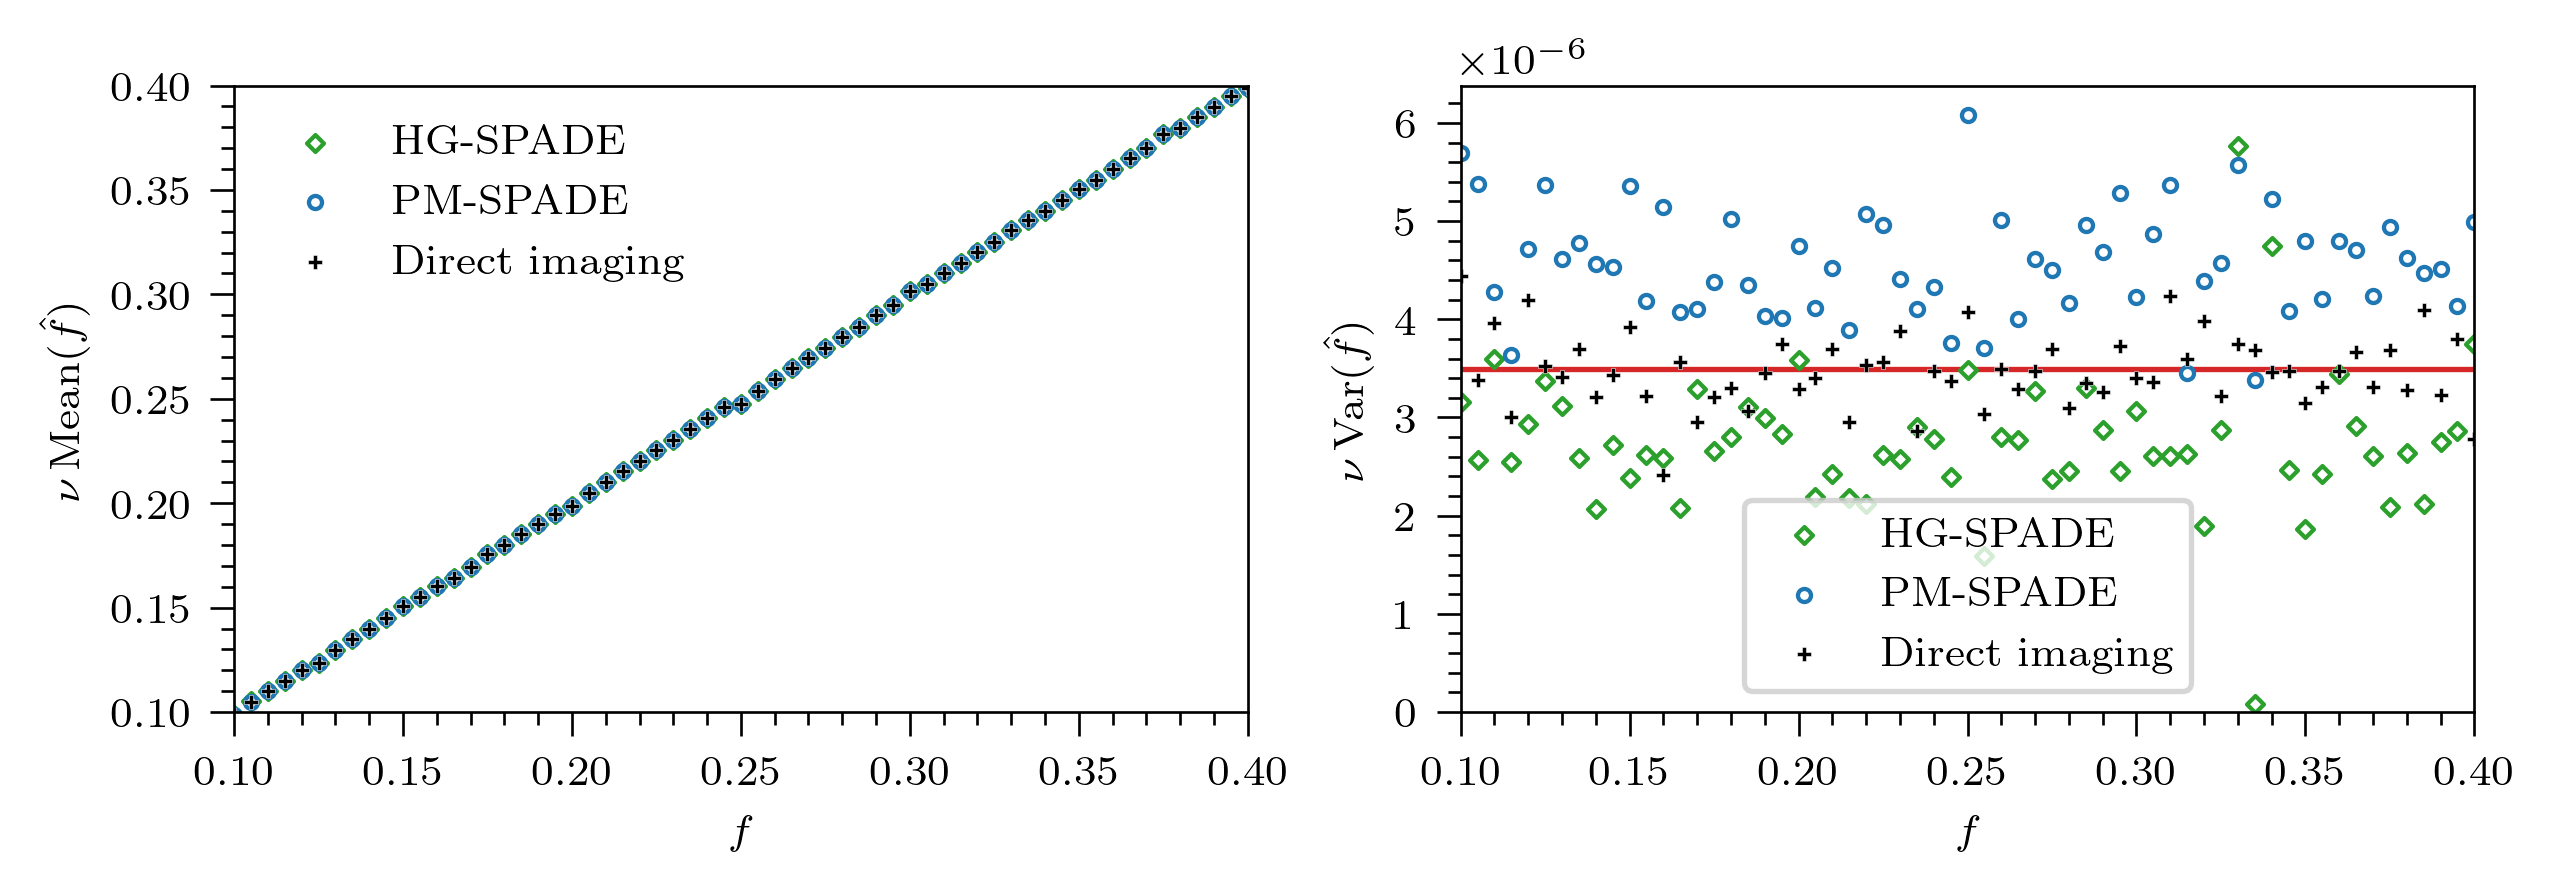

In [39]:
plt.rcParams['figure.figsize'] = (6.6, 3)

plt.subplot(1, 2, 1)

plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[0]), label=r'HG-SPADE', **hg_params)
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[1]), label=r'PM-SPADE', **spade_params)
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[2]), label=r'Direct imaging', **di_params)

plt.legend(frameon=False)
plt.xlim(0.1, 0.4)
plt.ylim(0.1, 0.4)

plt.xlabel(r'$f$')
plt.ylabel(r'$\nu \operatorname{Mean}(\hat f)$')

plt.gca().set_box_aspect(0.618)

plt.subplot(1, 2, 2)

plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[0]), label=r'HG-SPADE', **hg_params)
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[1]), label=r'PM-SPADE', **spade_params)
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[2]), label=r'Direct imaging', **di_params)

plt.axhline(1/DI.ApproxCFI(DMD.A(5) * 4 / pi), color='tab:red', zorder=0)
plt.xlim(0.1, 0.4)
plt.ylim(0, None)

plt.xlabel(r'$f$')
plt.ylabel(r'$\nu \operatorname{Var}(\hat f)$')

plt.gca().yaxis.set_major_formatter(formatter)
plt.gca().set_box_aspect(0.618)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

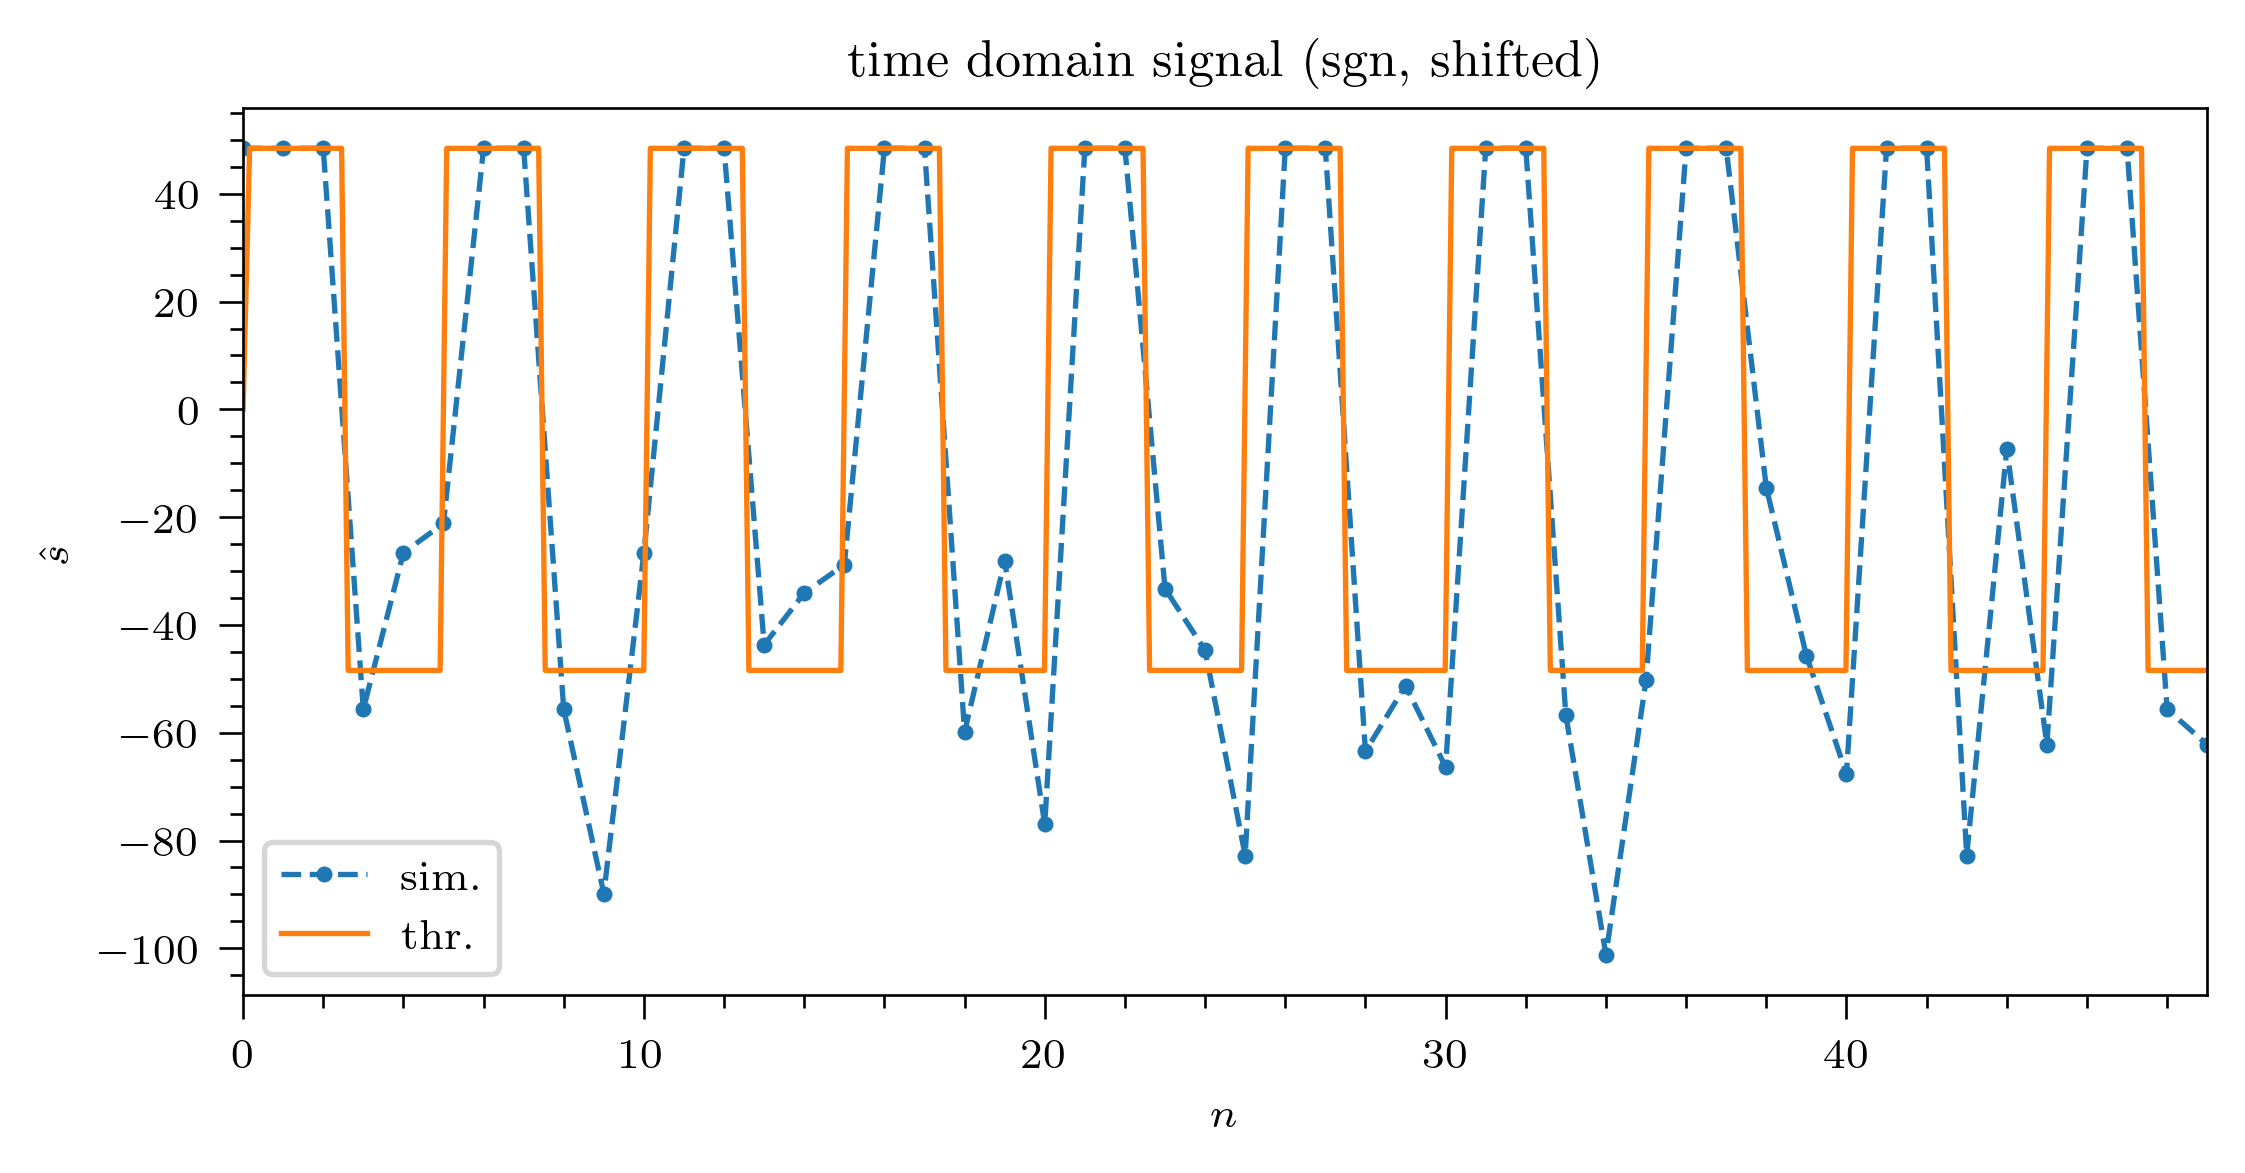

In [58]:
c = Simulator('hg', DMD.A(5), 0.2, waveform='sign').gen()
c.td_est()

plt.plot(c.time_domain[0], label='sim.', linestyle='--', marker='o')
plt.plot(np.linspace(0, 49, 300), DMD.A(5) * np.sign(np.sin(0.2 * 2*pi * np.linspace(0, 49, 300))), label='thr.')
plt.xlim(0, 49)
plt.xlabel(r'$n$')
plt.ylabel(r'$\hat s$')
plt.title(r'time domain signal (sgn, shifted)')
plt.legend()
plt.show()